<h1>RFM analysis of an e-commerce company</h1>

<h4>1.1 Import libraries</h4>

In [21]:
from operator import index

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from openpyxl.styles.builtins import headline_1

<h4>1.2 Import database</h4>

In [22]:
df = pd.read_csv('data/Online_Sales.csv')
df.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status
0,17850,16679,1/1/2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used
1,17850,16680,1/1/2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used
2,17850,16681,1/1/2019,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used
3,17850,16682,1/1/2019,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used
4,17850,16682,1/1/2019,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used


<h1>The customer's RFM score is calculated on a 1-5 scale by calculating their:</h1>

<h4>Recency (how recently was their last purchase)</h4>
<h4>Frequency (how often they purchase)</h4>
<h4>Monetization (how much they spend)</h4>

<h2>Recency Score</h2>
<h4>criteria:</h4>
-Consider current date as 01/01/2020<br>
-1 point: January / February (2019)<br>
-2 points: March / April<br>
-3 points: May / June/ July<br>
-4 points: August / September / October<br>
-5 points: November / December (2019)<br>

<h4>2.1 Isolate the transaction's month</h4>

In [23]:
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], format='%m/%d/%Y')
df['Transaction_Month'] = df['Transaction_Date'].dt.strftime('%m').astype('Int64')
df.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Transaction_Month
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,1
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,1
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,1
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,1
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,1


<h4>2.2 Get the client's most recent purchase month</h4>

In [24]:
df['Latest_Purchase'] = df.groupby('CustomerID')['Transaction_Month'].transform('max')
df.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Transaction_Month,Latest_Purchase
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,1,1
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,1,1
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,1,1
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,1,1
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,1,1


<h4>2.3 Create a function to calculate the client's score based on the given criteria, <br>then create a new column containing their recency score</h4>

In [25]:
def calculate_recency(value):
    if value <= 2:
        return 1
    elif value <= 4:
        return 2
    elif value <= 7:
        return 3
    elif value <= 10:
        return 4
    else:
        return 5

df['Recency_Score'] = df['Latest_Purchase'].apply(calculate_recency)
df.tail()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Transaction_Month,Latest_Purchase,Recency_Score
52919,14410,48493,2019-12-31,GGOENEBB078899,Nest Cam Indoor Security Camera - USA,Nest-USA,1,121.30,6.50,Clicked,12,12,5
52920,14410,48494,2019-12-31,GGOEGAEB091117,Google Zip Hoodie Black,Apparel,1,48.92,6.50,Used,12,12,5
52921,14410,48495,2019-12-31,GGOENEBQ084699,Nest Learning Thermostat 3rd Gen-USA - White,Nest-USA,1,151.88,6.50,Used,12,12,5
52922,14600,48496,2019-12-31,GGOENEBQ079199,Nest Protect Smoke + CO White Wired Alarm-USA,Nest-USA,5,80.52,6.50,Clicked,12,12,5
52923,14600,48497,2019-12-31,GGOENEBQ079099,Nest Protect Smoke + CO White Battery Alarm-USA,Nest-USA,4,80.52,19.99,Clicked,12,12,5


<h2>Frequecency Score</h2>
<h4>3.1 Finding out average number of purchases so scoring criteria can be defined</h4>

In [26]:
total_purchases = df['CustomerID'].value_counts()
frequency_score = pd.DataFrame({'Frequency_Score': total_purchases}).reset_index()
frequency_score

,CustomerID,Frequency_Score
0,12748,695
1,15311,587
2,14606,575
3,17841,572
4,14911,523
...,...,...
1463,12755,1
1464,18017,1
1465,16711,1
1466,17291,1


In [27]:
print(frequency_score['Frequency_Score'].unique())
print('\nTotal mean: ', frequency_score['Frequency_Score'].mean())
print('Unique mean:', frequency_score['Frequency_Score'].unique().mean())

[695 587 575 572 523 366 315 297 290 261 260 250 242 241 223 213 210 199
 193 187 183 175 171 170 168 163 161 160 159 157 155 149 147 146 144 143
 141 138 137 134 133 131 130 129 128 127 126 125 124 123 122 121 119 118
 117 116 115 114 113 112 110 106 105 104 103 102 101 100  99  98  96  95
  94  93  92  91  90  89  88  87  86  85  84  83  82  81  80  79  78  77
  76  75  74  73  72  71  70  69  67  66  65  64  63  62  61  60  59  58
  57  56  55  54  53  52  51  50  49  48  47  46  45  44  43  42  41  40
  39  38  37  36  35  34  33  32  31  30  29  28  27  26  25  24  23  22
  21  20  19  18  17  16  15  14  13  12  11  10   9   8   7   6   5   4
   3   2   1]

Total mean:  36.05177111716621
Unique mean: 108.23636363636363


<h4>criteria:</h4>
<p>
    -1 point: less than 15 purchases, casual or one-off customer<br>
    -2 points: between 16-35 purchases, below average customer<br>
    -3 points: between 36-70 purchases, average customer<br>
    -4 points: between 71-150 purchases, above average customer<br>
    -5 points: more than 150 purchases, loyal and high value customer<br>
</p>

In [28]:
df['Total_Purchases'] = df['CustomerID'].map(total_purchases)
df.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Transaction_Month,Latest_Purchase,Recency_Score,Total_Purchases
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,1,1,1,297
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,1,1,1,297
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,1,1,1,297
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,1,1,1,297
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,1,1,1,297


<h4>3.2 Create a function to calculate the client's score based on the given criteria, <br>then create a new column containing their frequency score</h4>


In [29]:
def calculate_frequency(value):
    if value <= 15:
        return 1
    elif value <= 35:
        return 2
    elif value <= 75:
        return 3
    elif value <= 150:
        return 4
    else:
        return 5

df['Frequency_Score'] = df['Total_Purchases'].map(calculate_frequency)
df.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Transaction_Month,Latest_Purchase,Recency_Score,Total_Purchases,Frequency_Score
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,1,1,1,297,5
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,1,1,1,297,5
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,1,1,1,297,5
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,1,1,1,297,5
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,1,1,1,297,5


<h2>Monetization Score</h2>
<h4>4.1 Finding out money spent by customer so scoring criteria can be defined</h4>

In [30]:
df['Total_Price'] = df['Quantity'] * df['Avg_Price']
df.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Transaction_Month,Latest_Purchase,Recency_Score,Total_Purchases,Frequency_Score,Total_Price
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,1,1,1,297,5,153.71
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,1,1,1,297,5,153.71
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,1,1,1,297,5,2.05
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,1,1,1,297,5,87.65
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,1,1,1,297,5,16.50


In [31]:
df['Total_Spent'] = df.groupby('CustomerID')['Total_Price'].transform('sum')
df.head(10)

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Transaction_Month,Latest_Purchase,Recency_Score,Total_Purchases,Frequency_Score,Total_Price,Total_Spent
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,1,1,1,297,5,153.71,34551.40
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,1,1,1,297,5,153.71,34551.40
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,1,1,1,297,5,2.05,34551.40
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,1,1,1,297,5,87.65,34551.40
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,1,1,1,297,5,16.50,34551.40
5,17850,16682,2019-01-01,GGOEGBMJ013399,Sport Bag,Bags,15,5.15,6.5,Used,1,1,1,297,5,77.25,34551.40
6,17850,16682,2019-01-01,GGOEGDHC018299,Google 22 oz Water Bottle,Drinkware,15,3.08,6.5,Not Used,1,1,1,297,5,46.20,34551.40
7,17850,16682,2019-01-01,GGOEGDHG014499,Google Infuser-Top Water Bottle,Drinkware,15,10.31,6.5,Clicked,1,1,1,297,5,154.65,34551.40
8,17850,16682,2019-01-01,GGOEGDWC020199,Engraved Ceramic Google Mug,Drinkware,5,9.27,6.5,Used,1,1,1,297,5,46.35,34551.40
9,13047,16682,2019-01-01,GGOEGGOA017399,Maze Pen,Office,52,0.98,6.5,Used,1,12,5,44,3,50.96,3048.79


<h4>4.2 Create a boxplot, to identify outliers and the average value spent by customer</h4>

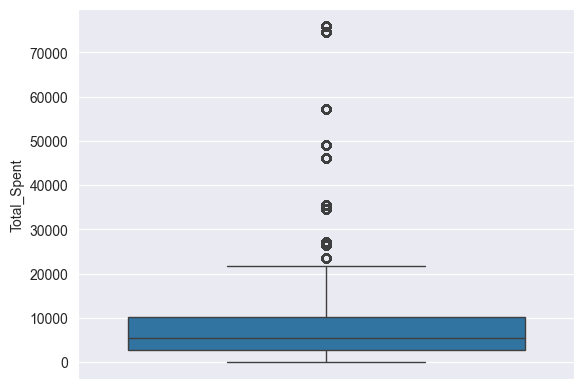

In [32]:
sns.boxplot(df['Total_Spent']);

<h4>4.3 We have identified we have some big outliers, and also that the 50% mark is at around $5_000</h4>

<h4>criteria:</h4>
<p>
    -1 point: less than \$1000, low value customer<br>
    -2 points: between \$1000 - \$4000, below average customer<br>
    -3 points: between \$4000 - \$6000, average customer<br>
    -4 points: between \$6000 - \$10_000, above average customer<br>
    -5 points: more than $10_000, high value customer<br>
</p>

<h4>4.4 Create a function to calculate the client's score based on the given criteria, <br>then create a new column containing their monetization score</h4>

In [33]:
def calculate_monetization(value):
    if value <= 1000:
        return 1
    elif value <= 4000:
        return 2
    elif value <= 6000:
        return 3
    elif value <= 10000:
        return 4
    else:
        return 5

df['Monetization_Score'] = df['Total_Spent'].map(calculate_monetization)
df.tail()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Transaction_Month,Latest_Purchase,Recency_Score,Total_Purchases,Frequency_Score,Total_Price,Total_Spent,Monetization_Score
52919,14410,48493,2019-12-31,GGOENEBB078899,Nest Cam Indoor Security Camera - USA,Nest-USA,1,121.30,6.50,Clicked,12,12,5,8,1,121.30,1108.99,2
52920,14410,48494,2019-12-31,GGOEGAEB091117,Google Zip Hoodie Black,Apparel,1,48.92,6.50,Used,12,12,5,8,1,48.92,1108.99,2
52921,14410,48495,2019-12-31,GGOENEBQ084699,Nest Learning Thermostat 3rd Gen-USA - White,Nest-USA,1,151.88,6.50,Used,12,12,5,8,1,151.88,1108.99,2
52922,14600,48496,2019-12-31,GGOENEBQ079199,Nest Protect Smoke + CO White Wired Alarm-USA,Nest-USA,5,80.52,6.50,Clicked,12,12,5,2,1,402.60,724.68,1
52923,14600,48497,2019-12-31,GGOENEBQ079099,Nest Protect Smoke + CO White Battery Alarm-USA,Nest-USA,4,80.52,19.99,Clicked,12,12,5,2,1,322.08,724.68,1


b<h1>Calculate total RFM Score</h1>

<h4>5.1 Create the total score column, which contains the average of the three different scores</h4>

In [34]:
df['RFM_Score'] = ((df['Recency_Score'] + df['Frequency_Score'] + df['Monetization_Score']) / 3).round(1)
df.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Transaction_Month,Latest_Purchase,Recency_Score,Total_Purchases,Frequency_Score,Total_Price,Total_Spent,Monetization_Score,RFM_Score
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,1,1,1,297,5,153.71,34551.4,5,3.7
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,1,1,1,297,5,153.71,34551.4,5,3.7
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,1,1,1,297,5,2.05,34551.4,5,3.7
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,1,1,1,297,5,87.65,34551.4,5,3.7
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,1,1,1,297,5,16.50,34551.4,5,3.7


<h4>5.2 Create a new DataFrame, with only the customer's ID and their scores</h4>

In [35]:
Customers_Scores = df[['CustomerID', 'Recency_Score', 'Frequency_Score', 'Monetization_Score', 'RFM_Score']].groupby('CustomerID', as_index=False).first()
Customers_Scores.head()

,CustomerID,Recency_Score,Frequency_Score,Monetization_Score,RFM_Score
0,12346,4,1,1,2.0
1,12347,5,3,5,4.3
2,12348,4,2,2,2.7
3,12350,5,2,2,3.0
4,12356,4,3,2,3.0


<h4>5.3 Sort the DataFrame from the highest total score to the lowest, so it's easier to identify the "best" and "worst" customers</h4>

In [36]:
Customers_Scores = Customers_Scores.sort_values('RFM_Score', ascending=False).reset_index()
Customers_Scores.drop('index', axis=1, inplace=True)
Customers_Scores

,CustomerID,Recency_Score,Frequency_Score,Monetization_Score,RFM_Score
0,15311,5,5,5,5.0
1,14911,5,5,5,5.0
2,15039,5,5,5,5.0
3,12501,5,5,5,5.0
4,12539,5,5,5,5.0
...,...,...,...,...,...
1463,13747,1,1,1,1.0
1464,13748,1,1,1,1.0
1465,13831,1,1,1,1.0
1466,16835,1,1,1,1.0


In [39]:
print('Nota media: ', Customers_Scores['RFM_Score'].mean())

Nota media:  2.578133514986376


<h4>Identify our customers with the maximum score, then plan the next step, like directed marketing programs, etc.</h4>

In [40]:
top_clients = Customers_Scores.query('RFM_Score == 5')['CustomerID'].to_list()
top_clients

[15311,
 14911,
 15039,
 12501,
 12539,
 15719,
 18041,
 15601,
 15808,
 17841,
 14606,
 14527,
 12681,
 14085,
 17511,
 14298,
 13174,
 13089,
 17337]